# Setting up

In [29]:
# Se necessário, instalar:
# !pip install spacy transformers torch pandas matplotlib seaborn scikit-learn
# !python -m spacy download pt_core_news_lg

In [30]:
import json
import pandas as pd
import numpy as np
import spacy
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline, AutoTokenizer, AutoModel
from sklearn.manifold import TSNE

In [31]:
# CARREGAMENTO DOS DADOS
with open('signos.json', 'r', encoding='utf-8') as f:
    data = json.load(f)


In [32]:
import re

# IMPORTAÇÃO COMPLETA
df = pd.DataFrame([info for signo, info in data.items()])

# Adicionamos a coluna do nome do signo (que estava na chave principal)
df.insert(0, 'Signo', [s.capitalize() for s in data.keys()])

# FUNÇÃO DE PADRONIZAÇÃO (RENOVAR COLUNAS)
mapeamento = {
    'Jeito de ser': 'Perfil',
    'Amor': 'Amor',
    'beijo': 'Beijo',
    'Família': 'Família',
    'Trabalho': 'Trabalho',
    'Amizade': 'Amizade',
    'mãe ou pai': 'Parentalidade',
    'criança': 'Infância',
    'Saúde': 'Saúde',
    'Principais qualidade': 'Qualidades', # Pega 'Principais qualidade de [Signo]'
    'Defeitinhos': 'Defeitos',
    'motivos para amar': 'Motivos_Para_Amar'
}

def limpar_nome_coluna(col_name):
    for chave, novo_nome in mapeamento.items():
        if chave.lower() in col_name.lower():
            return novo_nome
    return col_name

# Aplicando a renomeação em todas as colunas do DataFrame
df.columns = [limpar_nome_coluna(c) for c in df.columns]

# FILTRAGEM
# Como o JSON tem muitas colunas (Salmo, Orixá, etc), selecionamos apenas as que padronizamos
colunas_desejadas = ['Signo', 'Elemento', 'Regente', 'Perfil', 'Amor', 'Beijo', 'Família',
                     'Trabalho', 'Amizade', 'Parentalidade', 'Infância', 'Saúde',
                     'Qualidades', 'Defeitos', 'Motivos_Para_Amar']

# Filtramos apenas as colunas que existem no mapeamento (evita erro se alguma faltar)
df_final = df[[c for c in colunas_desejadas if c in df.columns]]

In [33]:
# Limpando a tabela com colunas repetidas derivadas do formato de colunas anterior
# Transpomos o DF para que as colunas virem linhas
df_t = df.T

# Agrupamos pelo índice (que eram os nomes das colunas)
# O .first() vai ignorar os NaNs e pegar o dado real de cada signo
df_consolidado_t = df_t.groupby(level=0).first()

# Transpomos de volta para o formato original
df_final = df_consolidado_t.T

# 4. Reordenar (garantindo que as colunas existem)
colunas_ordem = ['Signo', 'Elemento', 'Perfil', 'Amor', 'Beijo', 'Trabalho',
                 'Família', 'Amizade', 'Qualidades', 'Defeitos']

colunas_existentes = [c for c in colunas_ordem if c in df_final.columns]
df_final = df_final[colunas_existentes]

# Verificação
print(f"Colunas consolidadas: {df_final.columns.tolist()}")
display(df_final.head())

Colunas consolidadas: ['Signo', 'Elemento', 'Perfil', 'Amor', 'Beijo', 'Trabalho', 'Família', 'Amizade', 'Qualidades', 'Defeitos']


,Signo,Elemento,Perfil,Amor,Beijo,Trabalho,Família,Amizade,Qualidades,Defeitos
0,Aries,Fogo,"Áries é o primeiro signo do Zodíaco, o que exp...",A impetuosidade com que se lança na estrada da...,É um beijo cheio de vontade e calor! Também é ...,Seus principais atributos – a coragem e o dina...,"Em família, você gosta de dar a última palavra...","Em família, você gosta de dar a última palavra...","[Dinamismo, Coragem, Independência, Entusiasmo...","[Impaciência, Egoísmo, Agressividade, Orgulho,..."
1,Touro,Terra,A frase “Devagar se vai ao longe” deveria faze...,"Para ser feliz no amor, Touro precisa, sobretu...","Como a sensualidade corre nas suas veias, seu ...","Na vida profissional, você se destaca pela cap...",É na sua casa que você se sente livre para des...,"Para Touro, amizade é para vida toda! Por isso...","[Determinação, Paciência, Persistência, Sensat...","[Teimosia, Possessividade, Inflexibilidade, Te..."
2,Gemeos,Ar,"Dentro das suas veias, correm a curiosidade, a...","Antes de se envolver com alguém, você precisa ...",Geminianos nunca beijam da mesma forma: num de...,A criatividade é sua principal arma no mercado...,Você não deixa a peteca cair em casa! Mesmo qu...,"Seu esporte preferido é fazer amizades, Gêmeos...","[Poder de comunicação, Curiosidade, Otimismo, ...","[Inconstância, Indiscrição, Superficialidade, ..."
3,Cancer,Água,"Sensibilidade, sentimento, saudosismo, intuiçã...",O eixo da sua vida é a estabilidade no amor. P...,Seu beijo não tem hora para acabar: você gosta...,A sua percepção privilegiada é seu diferencial...,"Como a família é o norte da sua vida, é no con...","Sua lista de amigos não é grande. Na verdade, ...","[Intuição, Sensibilidade, Instinto de proteção...","[Dependência emocional, Insegurança, Possessiv..."
4,Leao,Fogo,Da mesma forma que o rugido do leão faz a selv...,"Para Leão, o amor ideal deve ter sabor de desc...","Seu beijo é cheio de desejo e calor, já que Le...",Você encara o trabalho como um campo aberto pa...,"Junto à família, Leão não foge da sua essência...","Você adora a companhia dos amigos, porque a pr...","[1.Poder de sedução, Carisma, Otimismo, Genero...","[Vaidade, Arrogância, Egoísmo, Orgulho, Preguiça]"


In [34]:
df_final.columns

Index(['Signo', 'Elemento', 'Perfil', 'Amor', 'Beijo', 'Trabalho', 'Família',
       'Amizade', 'Qualidades', 'Defeitos'],
      dtype='str')

# NLP

In [35]:
# CONFIGURAÇÃO DAS FERRAMENTAS
# Carrega spaCy para PLN
nlp = spacy.load("pt_core_news_lg")

# Carrega Transformers para Sentimento e Embeddings
sentiment_pipe = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")
embed_tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
embed_model = AutoModel.from_pretrained("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# PROCESSAMENTO LINGUÍSTICO E SENTIMENTO
def processar_dados(texto):
    doc = nlp(texto)

    # NLP com spaCy
    tokens = [t.text for t in doc]
    lemas = [t.lemma_ for t in doc if not t.is_stop and t.is_alpha]
    pos = [t.pos_ for t in doc]
    entidades = [(ent.text, ent.label_) for ent in doc.ents]
    chunks = [chunk.text for chunk in doc.noun_chunks]
    sentencas = [sent.text for sent in doc.sents]

    # Sentimento (Transformers)
    sent_res = sentiment_pipe(texto[:512])[0]
    score = int(sent_res['label'].split()[0])

    # Embeddings (Transformers)
    inputs = embed_tokenizer(texto, return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = embed_model(**inputs)
    embedding = outputs.last_hidden_state.mean(dim=1).numpy().flatten()

    return pd.Series([lemas, entidades, chunks, sentencas, score, embedding])

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3666.62it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Todas as categorias de texto

In [36]:
# Lista das colunas que queremos processar
colunas_texto = ['Perfil', 'Amor', 'Beijo', 'Trabalho', 'Família', 'Amizade']

# Função para garantir que listas virem texto e NaNs virem string vazia
def tratar_texto(x):
    if isinstance(x, list):
        return ", ".join(x)
    return str(x) if pd.notnull(x) else ""

# Criando a coluna 'texto_completo' unindo tudo
df_final['texto_para_ia'] = df_final[colunas_texto].fillna("").agg(' '.join, axis=1)

# Adicionando Qualidades e Defeitos (tratando as listas)
df_final['texto_para_ia'] += " Qualidades: " + df_final['Qualidades'].apply(tratar_texto)
df_final['texto_para_ia'] += " Defeitos: " + df_final['Defeitos'].apply(tratar_texto)

In [37]:
print("Processando PLN, Sentimentos e Embeddings sobre o perfil completo... aguarde.")

# Agora passamos apenas a coluna 'texto_para_ia'
df_results = df_final['texto_para_ia'].apply(processar_dados)

# Criando as novas colunas no DataFrame original
df_final[['lemas', 'entidades', 'noun_chunks', 'sentencas', 'sentimento_score', 'embeddings']] = df_results

print("Concluído!")

Processando PLN, Sentimentos e Embeddings sobre o perfil completo... aguarde.
Concluído!


C:\Users\Beatriz\AppData\Local\Temp\ipykernel_23328\3099900626.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Signo', y='sentimento_score', data=df, palette='magma')


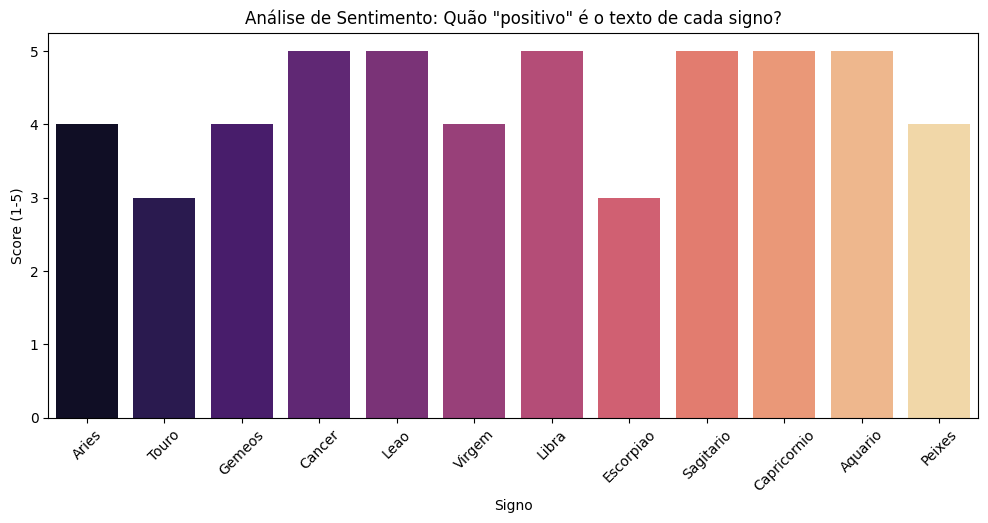

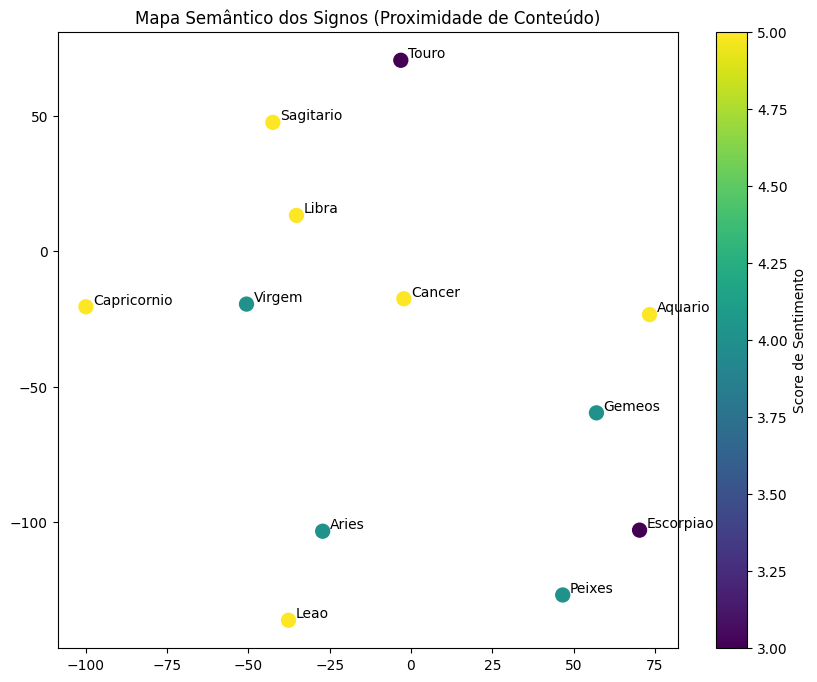


EXEMPLO DE PROCESSAMENTO DE LINGUAGEM NATURAL (Áries)
Signo: Aries

1. Sentenças (primeiras 2): ['Áries é o primeiro signo do Zodíaco, o que explica muita coisa sobre a sua vibrante personalidade.', 'Você gosta de decidir, dominar o romance, liderar sua equipe de trabalho.']

2. Entidades Nomeadas (NER): [('Zodíaco', 'PER'), ('Adora', 'PER'), ('Marte', 'LOC'), ('Áries', 'PER'), ('Paquera', 'LOC'), ('Tchau', 'PER'), ('paquera', 'LOC'), ('Independência', 'MISC'), ('Entusiasmo', 'PER'), ('Ousadia Defeitos: Impaciência, Egoísmo, Agressividade', 'MISC'), ('Orgulho', 'MISC')]

3. Noun Chunks (primeiros 5): ['Áries', 'Zodíaco', 'o', 'que', 'muita coisa']

4. Lemas (primeiros 10 sem stopwords): ['Áries', 'signo', 'Zodíaco', 'explicar', 'muito', 'vibrante', 'personalidade', 'gostar', 'decidir', 'dominar']


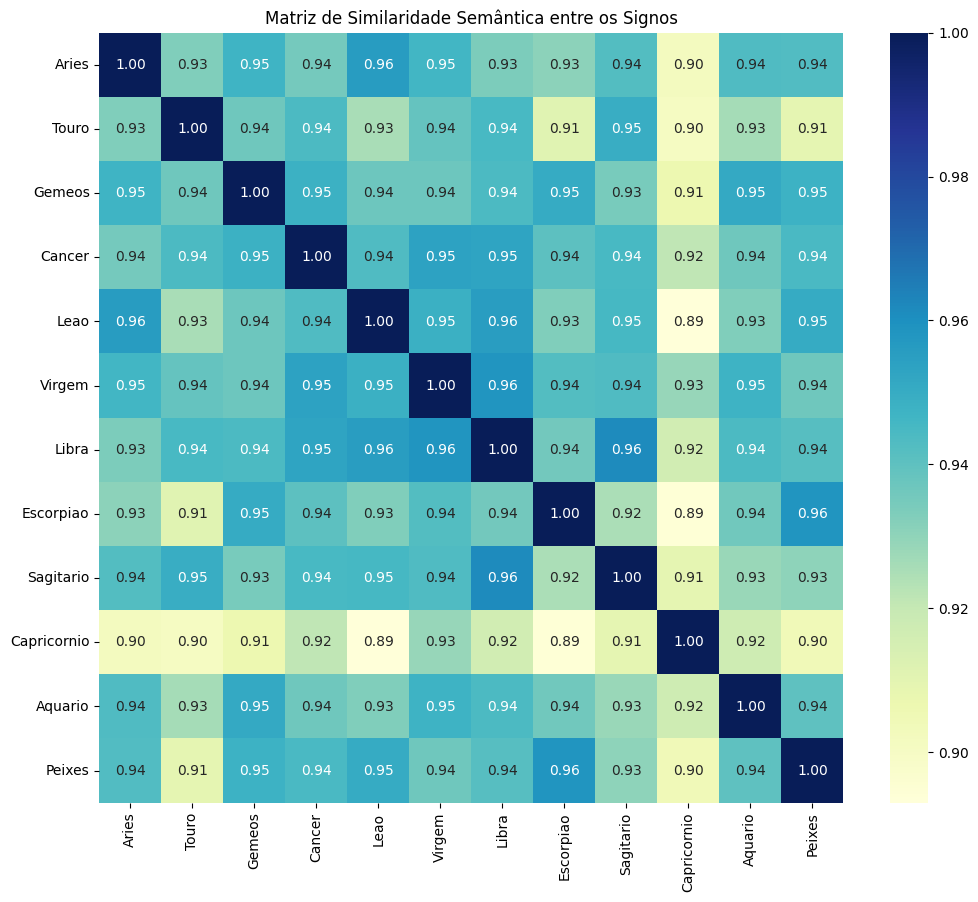

In [38]:
# VISUALIZAÇÃO
# GRÁFICO DE SENTIMENTOS
df = df_final

plt.figure(figsize=(12, 5))
sns.barplot(x='Signo', y='sentimento_score', data=df, palette='magma')
plt.title('Análise de Sentimento: Quão "positivo" é o texto de cada signo?')
plt.ylabel('Score (1-5)')
plt.xticks(rotation=45)
plt.show()


# MAPA SEMÂNTICO (TSNE)
# CORREÇÃO AQUI: Convertendo a lista de embeddings em uma matriz NumPy 2D
matrix_embeddings = np.vstack(df['embeddings'].values)

# Redução de dimensionalidade
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(df)-1), init='pca', learning_rate='auto')
vis_dims = tsne.fit_transform(matrix_embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(vis_dims[:, 0], vis_dims[:, 1], c=df['sentimento_score'], cmap='viridis', s=100)

# Adicionar rótulos aos pontos
for i, signo in enumerate(df['Signo']):
    plt.annotate(signo, (vis_dims[i, 0], vis_dims[i, 1]), xytext=(5, 2), textcoords='offset points')

plt.title('Mapa Semântico dos Signos (Proximidade de Conteúdo)')
plt.colorbar(label='Score de Sentimento')
plt.show()

# DEMONSTRAÇÃO DOS RESULTADOS DE PLN
print("\n" + "="*50)
print("EXEMPLO DE PROCESSAMENTO DE LINGUAGEM NATURAL (Áries)")
print("="*50)
exemplo = df.iloc[0]
print(f"Signo: {exemplo['Signo']}")
print(f"\n1. Sentenças (primeiras 2): {exemplo['sentencas'][:2]}")
print(f"\n2. Entidades Nomeadas (NER): {exemplo['entidades']}")
print(f"\n3. Noun Chunks (primeiros 5): {exemplo['noun_chunks'][:5]}")
print(f"\n4. Lemas (primeiros 10 sem stopwords): {exemplo['lemas'][:10]}")

from sklearn.metrics.pairwise import cosine_similarity

# Calcular a matriz de similaridade entre todos os embeddings
# np.stack transforma a coluna de listas em uma matriz 2D
sim_matrix = cosine_similarity(np.stack(df['embeddings'].values))

# Criar o Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(sim_matrix, annot=True, fmt=".2f", cmap='YlGnBu',
            xticklabels=df['Signo'].values,
            yticklabels=df['Signo'].values)

plt.title('Matriz de Similaridade Semântica entre os Signos')
plt.show()

## Mapa de palavras (geral)

In [39]:
# !pip install gensim wordcloud textblob -q
# !python -m spacy download pt_core_news_lg -q

In [40]:
from wordcloud import WordCloud
from gensim import corpora, models
from textblob import TextBlob

nlp = spacy.load("pt_core_news_lg")

def processar_para_analise(texto):
    # Garante que o texto não é nulo antes de processar
    if pd.isna(texto):
        return []
    doc = nlp(texto.lower())
    # Filtro: Substantivos (NOUN) e Adjetivos (ADJ)
    return [t.lemma_ for t in doc if t.pos_ in ['NOUN', 'ADJ'] and not t.is_stop and t.is_alpha]

In [41]:
# Selecionar categoria:
categ = 'texto_para_ia' # < Preencher aqui

# Aplicando a função à coluna da categoria
df_final['Lemas_Analise'] = df_final[categ].apply(processar_para_analise)

# Para verificar o resultado
print(df_final[['Signo', categ, 'Lemas_Analise']].head())

    Signo                                      texto_para_ia  \
0   Aries  Áries é o primeiro signo do Zodíaco, o que exp...   
1   Touro  A frase “Devagar se vai ao longe” deveria faze...   
2  Gemeos  Dentro das suas veias, correm a curiosidade, a...   
3  Cancer  Sensibilidade, sentimento, saudosismo, intuiçã...   
4    Leao  Da mesma forma que o rugido do leão faz a selv...   

                                       Lemas_Analise  
0  [árie, signo, zodíaco, vibrante, personalidade...  
1  [frase, rg, força, foco, fé, gente, frente, so...  
2  [veia, curiosidade, energia, desejo, movimento...  
3  [sensibilidade, sentimento, saudosismo, intuiç...  
4  [mesmo, rugido, leão, selva, tremer, magnetism...  


### Análise de Tópicos (LDA)
O que os astros estão dizendo ? (Carreira, Amor, Saúde?)

In [42]:
dicionario = corpora.Dictionary(df_final['Lemas_Analise'])
corpus = [dicionario.doc2bow(text) for text in df_final['Lemas_Analise']]

lda_model = models.LdaModel(corpus, num_topics=3, id2word=dicionario, passes=15)

print("Tópicos Dominantes no Horóscopo de Hoje:")
for idx, topic in lda_model.print_topics(-1):
    print(f"Tópico {idx}: {topic}")

Tópicos Dominantes no Horóscopo de Hoje:
Tópico 0: 0.016*"signo" + 0.014*"vida" + 0.013*"pessoa" + 0.010*"amigo" + 0.008*"amor" + 0.008*"beijo" + 0.006*"namoro" + 0.006*"mundo" + 0.005*"trabalho" + 0.005*"par"
Tópico 1: 0.010*"signo" + 0.009*"pessoa" + 0.009*"amigo" + 0.006*"namoro" + 0.006*"aquário" + 0.005*"beijo" + 0.005*"vida" + 0.005*"importante" + 0.005*"criatividade" + 0.005*"paquera"
Tópico 2: 0.014*"pessoa" + 0.011*"signo" + 0.011*"amigo" + 0.009*"escorpião" + 0.007*"beijo" + 0.007*"qualidade" + 0.007*"virgem" + 0.006*"vida" + 0.005*"namoro" + 0.004*"trabalho"


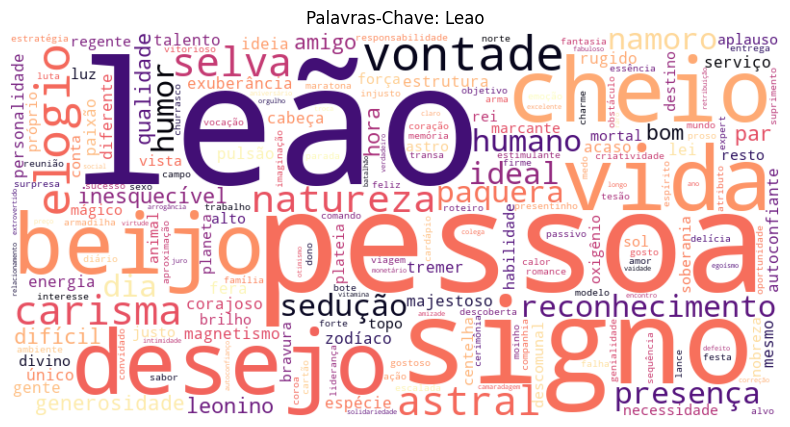

In [43]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def mostrar_nuvem(signo):
    lemas = df_final[df_final['Signo'] == signo]['Lemas_Analise'].values[0]
    texto = " ".join(lemas)

    wc = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(texto)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"Palavras-Chave: {signo}")
    plt.axis("off")
    plt.show()

mostrar_nuvem('Leao')

# Analisando por categorias específicas
Tomamos 3 categorias descritivas de signo (Perfil, amor e trabalho):

## Perfil (Jeito de Ser)

In [44]:
print("Processando PLN, Sentimentos e Embeddings... aguarde.")
# Aplicando a função e criando as colunas explicitamente
df[['lemas', 'entidades', 'noun_chunks', 'sentencas', 'sentimento_score', 'embeddings']] = df['Perfil'].apply(processar_dados)

Processando PLN, Sentimentos e Embeddings... aguarde.


C:\Users\Beatriz\AppData\Local\Temp\ipykernel_23328\3770209197.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Signo', y='sentimento_score', data=df, palette='magma')


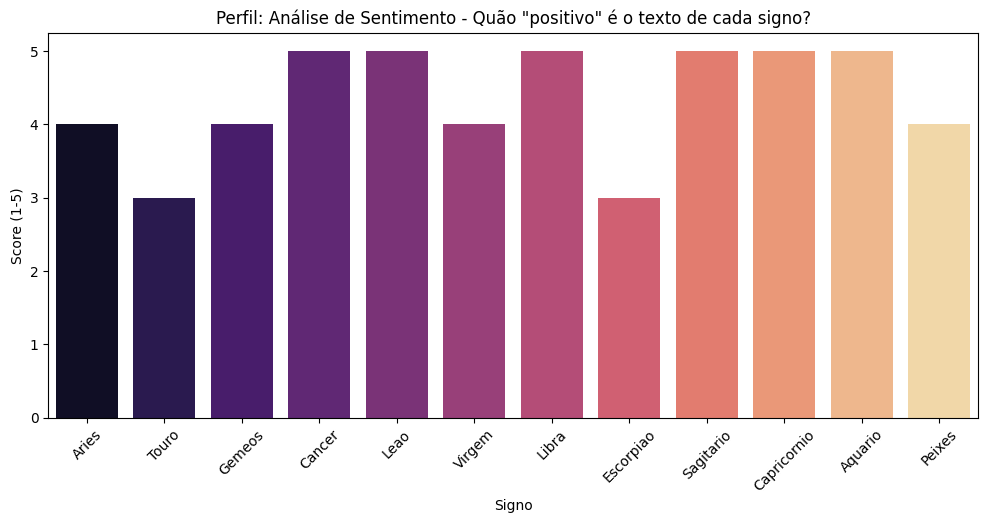

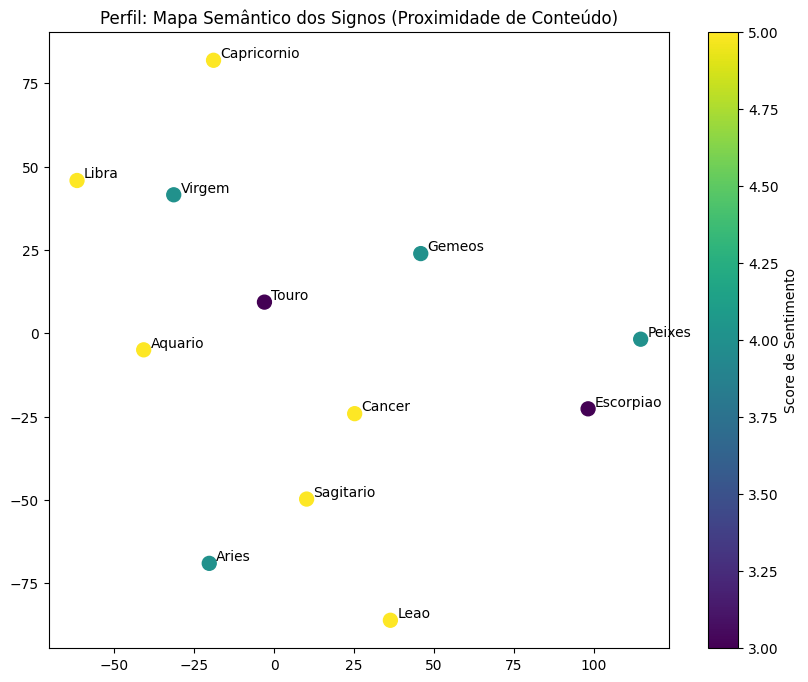

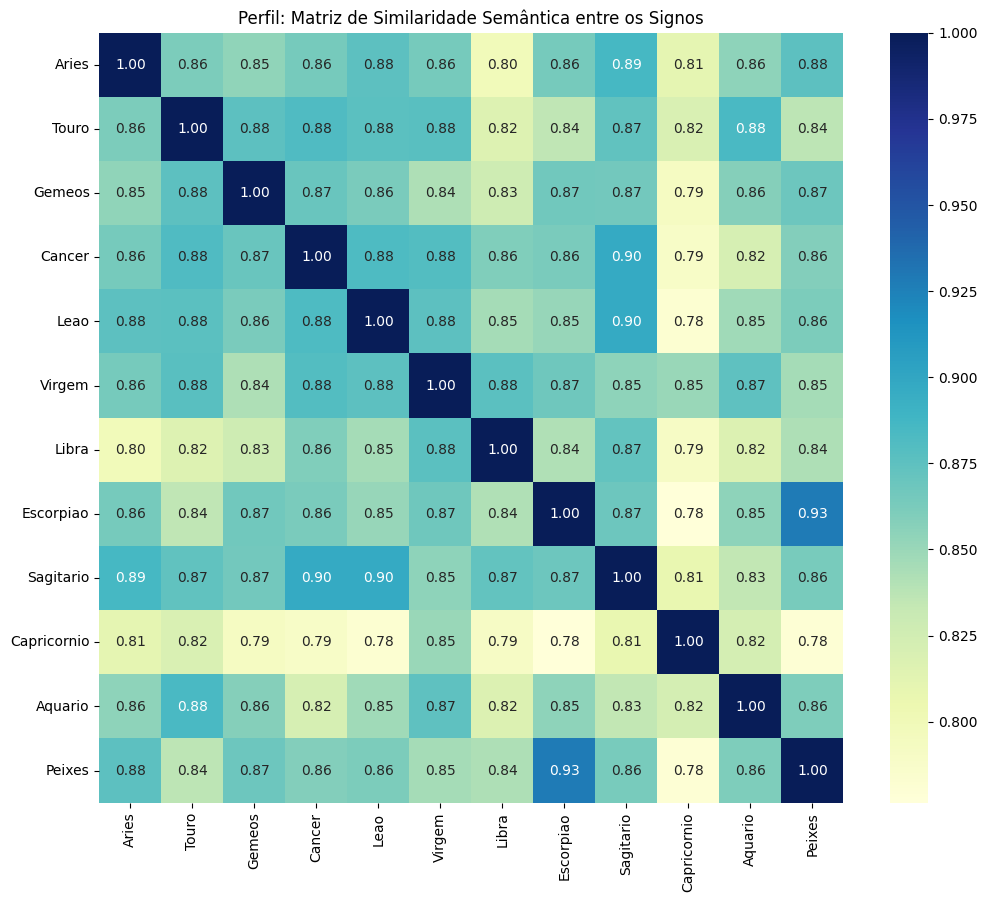

In [45]:
# VISUALIZAÇÃO
# GRÁFICO DE SENTIMENTOS (Amor)
plt.figure(figsize=(12, 5))
sns.barplot(x='Signo', y='sentimento_score', data=df, palette='magma')
plt.title('Perfil: Análise de Sentimento - Quão "positivo" é o texto de cada signo?')
plt.ylabel('Score (1-5)')
plt.xticks(rotation=45)
plt.show()

# MAPA SEMÂNTICO (TSNE)
# Convertendo a lista de embeddings em uma matriz NumPy 2D
matrix_embeddings = np.vstack(df['embeddings'].values)

# Redução de dimensionalidade
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(df)-1), init='pca', learning_rate='auto')
vis_dims = tsne.fit_transform(matrix_embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(vis_dims[:, 0], vis_dims[:, 1], c=df['sentimento_score'], cmap='viridis', s=100)

# Adicionar rótulos aos pontos
for i, signo in enumerate(df['Signo']):
    plt.annotate(signo, (vis_dims[i, 0], vis_dims[i, 1]), xytext=(5, 2), textcoords='offset points')

plt.title('Perfil: Mapa Semântico dos Signos (Proximidade de Conteúdo)')
plt.colorbar(label='Score de Sentimento')
plt.show()



### Heatmap
from sklearn.metrics.pairwise import cosine_similarity

# Calcular a matriz de similaridade entre todos os embeddings
# np.stack transforma a coluna de listas em uma matriz 2D
sim_matrix = cosine_similarity(np.stack(df['embeddings'].values))

# Criar o Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(sim_matrix, annot=True, fmt=".2f", cmap='YlGnBu',
            xticklabels=df['Signo'].values,
            yticklabels=df['Signo'].values)

plt.title('Perfil: Matriz de Similaridade Semântica entre os Signos')
plt.show()

No perfil (jeito de ser), similaridades maiores entre:

* Escorpião e peixes (água)
* Sagitário, leão e áries (fogo)

### Mapa de palavras (Perfil)

    Signo                                             Perfil  \
0   Aries  Áries é o primeiro signo do Zodíaco, o que exp...   
1   Touro  A frase “Devagar se vai ao longe” deveria faze...   
2  Gemeos  Dentro das suas veias, correm a curiosidade, a...   
3  Cancer  Sensibilidade, sentimento, saudosismo, intuiçã...   
4    Leao  Da mesma forma que o rugido do leão faz a selv...   

                                       Lemas_Analise  
0  [árie, signo, zodíaco, vibrante, personalidade...  
1  [frase, rg, força, foco, fé, gente, frente, so...  
2  [veia, curiosidade, energia, desejo, movimento...  
3  [sensibilidade, sentimento, saudosismo, intuiç...  
4  [mesmo, rugido, leão, selva, tremer, magnetism...  
Tópicos Dominantes no Horóscopo de Hoje:
Tópico 0: 0.017*"signo" + 0.014*"mundo" + 0.012*"pessoa" + 0.010*"planeta" + 0.009*"coisa" + 0.009*"vida" + 0.007*"energia" + 0.007*"sagitário" + 0.006*"interior" + 0.006*"palavra"
Tópico 1: 0.019*"signo" + 0.013*"vida" + 0.013*"pessoa" + 0.009

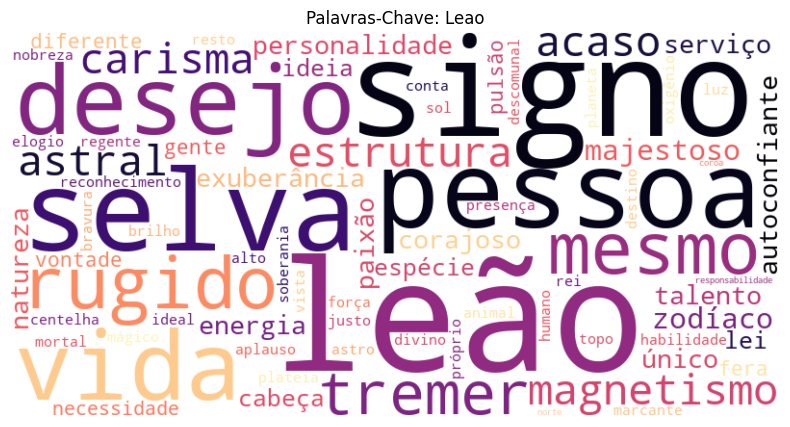

In [46]:
# Selecionar categoria:
categ = 'Perfil' # < Preencher aqui

# Aplicando a função à coluna da categoria
df_final['Lemas_Analise'] = df_final[categ].apply(processar_para_analise)

# Para verificar o resultado
print(df_final[['Signo', categ, 'Lemas_Analise']].head())

# Análise de Tópicos (LDA)
dicionario = corpora.Dictionary(df_final['Lemas_Analise'])
corpus = [dicionario.doc2bow(text) for text in df_final['Lemas_Analise']]

lda_model = models.LdaModel(corpus, num_topics=3, id2word=dicionario, passes=15)

print("Tópicos Dominantes no Horóscopo de Hoje:")
for idx, topic in lda_model.print_topics(-1):
    print(f"Tópico {idx}: {topic}")

# Exemplo de núvem, selecionando o signo de Leão:
mostrar_nuvem('Leao')

## Amor

In [47]:
print("Processando PLN, Sentimentos e Embeddings... aguarde.")

# Aplicando a função e criando as colunas explicitamente

df_final[['lemas', 'entidades', 'noun_chunks', 'sentencas', 'sentimento_score', 'embeddings']] = df_final['Amor'].apply(processar_dados)

Processando PLN, Sentimentos e Embeddings... aguarde.


In [48]:
print("Processando PLN, Sentimentos e Embeddings sobre o perfil completo... aguarde.")

# Agora passamos apenas a coluna 'texto_para_ia'
df_results = df_final['Amor'].apply(processar_dados)

# Criando as novas colunas no DataFrame original
df_final[['lemas', 'entidades', 'noun_chunks', 'sentencas', 'sentimento_score', 'embeddings']] = df_results

print("Concluído!")

Processando PLN, Sentimentos e Embeddings sobre o perfil completo... aguarde.
Concluído!


In [49]:
df = df_final

C:\Users\Beatriz\AppData\Local\Temp\ipykernel_23328\3056362481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Signo', y='sentimento_score', data=df, palette='magma')


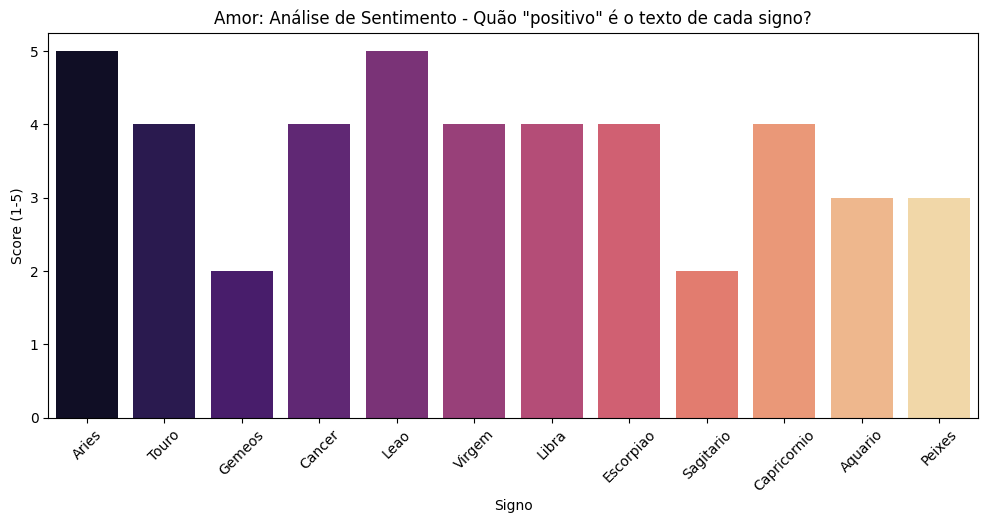

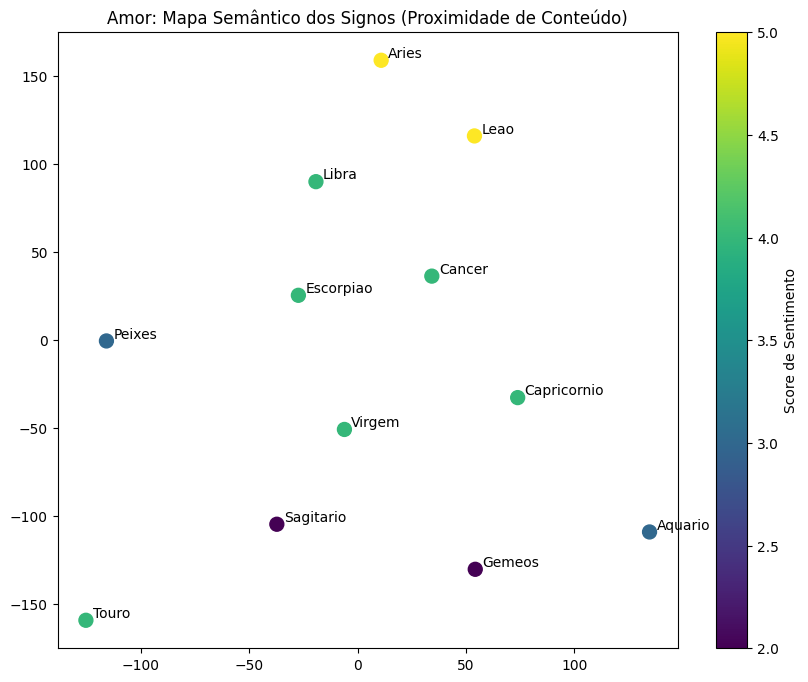


EXEMPLO DE PROCESSAMENTO DE LINGUAGEM NATURAL (Áries)
Signo: Aries

1. Sentenças (primeiras 2): ['A impetuosidade com que se lança na estrada da vida também dá o tom à sua forma de amar.', 'Você adora seduzir!']

2. Entidades Nomeadas (NER): [('Paquera', 'LOC'), ('Tchau', 'PER'), ('paquera', 'LOC')]

3. Noun Chunks (primeiros 5): ['A impetuosidade', 'que', 'estrada', 'vida', 'o tom']

4. Lemas (primeiros 10 sem stopwords): ['impetuosidade', 'lançar', 'estrada', 'vida', 'tom', 'amar', 'adorar', 'seduzir', 'abrir', 'coração']


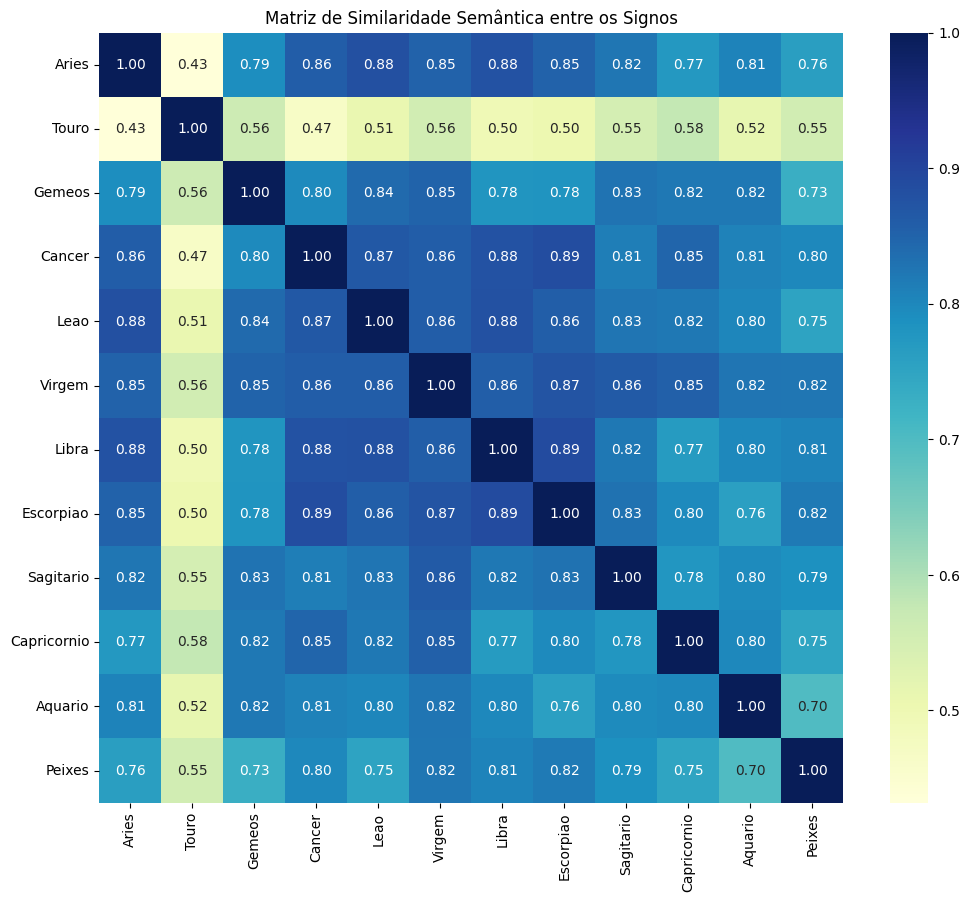

In [50]:
# VISUALIZAÇÃO
# GRÁFICO DE SENTIMENTOS (Amor)
plt.figure(figsize=(12, 5))
sns.barplot(x='Signo', y='sentimento_score', data=df, palette='magma')
plt.title('Amor: Análise de Sentimento - Quão "positivo" é o texto de cada signo?')
plt.ylabel('Score (1-5)')
plt.xticks(rotation=45)
plt.show()

# MAPA SEMÂNTICO (TSNE)
# Convertendo a lista de embeddings em uma matriz NumPy 2D
matrix_embeddings = np.vstack(df['embeddings'].values)

# Redução de dimensionalidade
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(df)-1), init='pca', learning_rate='auto')
vis_dims = tsne.fit_transform(matrix_embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(vis_dims[:, 0], vis_dims[:, 1], c=df['sentimento_score'], cmap='viridis', s=100)

# Adicionar rótulos aos pontos
for i, signo in enumerate(df['Signo']):
    plt.annotate(signo, (vis_dims[i, 0], vis_dims[i, 1]), xytext=(5, 2), textcoords='offset points')

plt.title('Amor: Mapa Semântico dos Signos (Proximidade de Conteúdo)')
plt.colorbar(label='Score de Sentimento')
plt.show()

# DEMONSTRAÇÃO DOS RESULTADOS DE PLN
print("\n" + "="*50)
print("EXEMPLO DE PROCESSAMENTO DE LINGUAGEM NATURAL (Áries)")
print("="*50)
exemplo = df.iloc[0]
print(f"Signo: {exemplo['Signo']}")
print(f"\n1. Sentenças (primeiras 2): {exemplo['sentencas'][:2]}")
print(f"\n2. Entidades Nomeadas (NER): {exemplo['entidades']}")
print(f"\n3. Noun Chunks (primeiros 5): {exemplo['noun_chunks'][:5]}")
print(f"\n4. Lemas (primeiros 10 sem stopwords): {exemplo['lemas'][:10]}")


## Heatmap

# Calcular a matriz de similaridade entre todos os embeddings
# np.stack transforma a coluna de listas em uma matriz 2D
sim_matrix = cosine_similarity(np.stack(df['embeddings'].values))

# Criar o Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(sim_matrix, annot=True, fmt=".2f", cmap='YlGnBu',
            xticklabels=df['Signo'].values,
            yticklabels=df['Signo'].values)

plt.title('Matriz de Similaridade Semântica entre os Signos')
plt.show()

No amor, a similaridade é muito grande entre todos os signos, menos o signo de touro que é diferente de todos por motivo desconhecido. Pode caber uma investigação mais profunda se necessário.

### Mapa de Palavras (Amor)

    Signo                                               Amor  \
0   Aries  A impetuosidade com que se lança na estrada da...   
1   Touro  Para ser feliz no amor, Touro precisa, sobretu...   
2  Gemeos  Antes de se envolver com alguém, você precisa ...   
3  Cancer  O eixo da sua vida é a estabilidade no amor. P...   
4    Leao  Para Leão, o amor ideal deve ter sabor de desc...   

                                       Lemas_Analise  
0  [impetuosidade, estrada, vida, tom, coração, a...  
1  [feliz, amor, touro, segurança, aventura, româ...  
2  [passo, certo, motivo, compromisso, independên...  
3  [eixo, vida, estabilidade, amor, calma, campo,...  
4  [leão, amor, ideal, sabor, descoberta, romance...  
Tópicos Dominantes no Horóscopo de Hoje:
Tópico 0: 0.023*"namoro" + 0.016*"par" + 0.016*"paquera" + 0.012*"dia" + 0.012*"ideal" + 0.012*"alvo" + 0.008*"compromisso" + 0.008*"surpresa" + 0.008*"desejo" + 0.008*"paixão"
Tópico 1: 0.028*"pessoa" + 0.022*"paquera" + 0.022*"par" + 0.022*"n

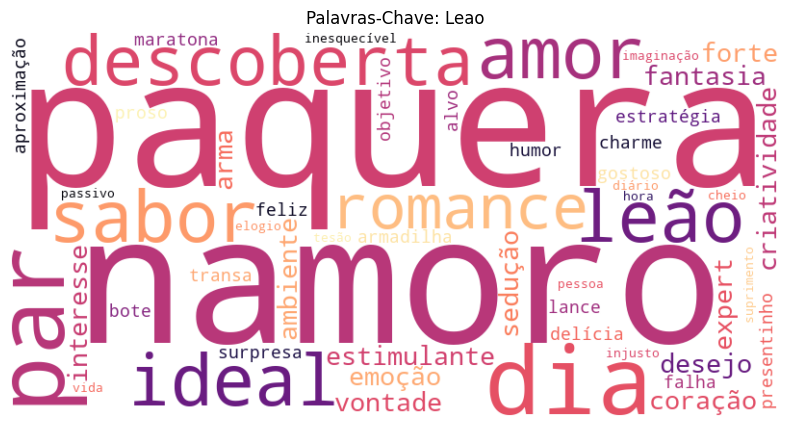

In [51]:
# Selecionar categoria:
categ = 'Amor' # < Preencher aqui

# Aplicando a função à coluna da categoria
df_final['Lemas_Analise'] = df_final[categ].apply(processar_para_analise)

# Para verificar o resultado
print(df_final[['Signo', categ, 'Lemas_Analise']].head())

# Análise de Tópicos (LDA)
dicionario = corpora.Dictionary(df_final['Lemas_Analise'])
corpus = [dicionario.doc2bow(text) for text in df_final['Lemas_Analise']]

lda_model = models.LdaModel(corpus, num_topics=3, id2word=dicionario, passes=15)

print("Tópicos Dominantes no Horóscopo de Hoje:")
for idx, topic in lda_model.print_topics(-1):
    print(f"Tópico {idx}: {topic}")

# Exemplo de núvem, selecionando o signo de Leão:
mostrar_nuvem('Leao')

## Trabalho

In [52]:
print("Processando PLN, Sentimentos e Embeddings... aguarde.")

# Aplicando a função e criando as colunas explicitamente

df_final[['lemas', 'entidades', 'noun_chunks', 'sentencas', 'sentimento_score', 'embeddings']] = df_final['Trabalho'].apply(processar_dados)

Processando PLN, Sentimentos e Embeddings... aguarde.


In [53]:

print("Processando PLN, Sentimentos e Embeddings sobre o perfil completo... aguarde.")

# Agora passamos apenas a coluna 'texto_para_ia'
df_results = df_final['Trabalho'].apply(processar_dados)

# Criando as novas colunas no DataFrame original
df_final[['lemas', 'entidades', 'noun_chunks', 'sentencas', 'sentimento_score', 'embeddings']] = df_results

print("Concluído!")

Processando PLN, Sentimentos e Embeddings sobre o perfil completo... aguarde.
Concluído!


In [54]:
df = df_final

C:\Users\Beatriz\AppData\Local\Temp\ipykernel_23328\1681493788.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Signo', y='sentimento_score', data=df, palette='magma')


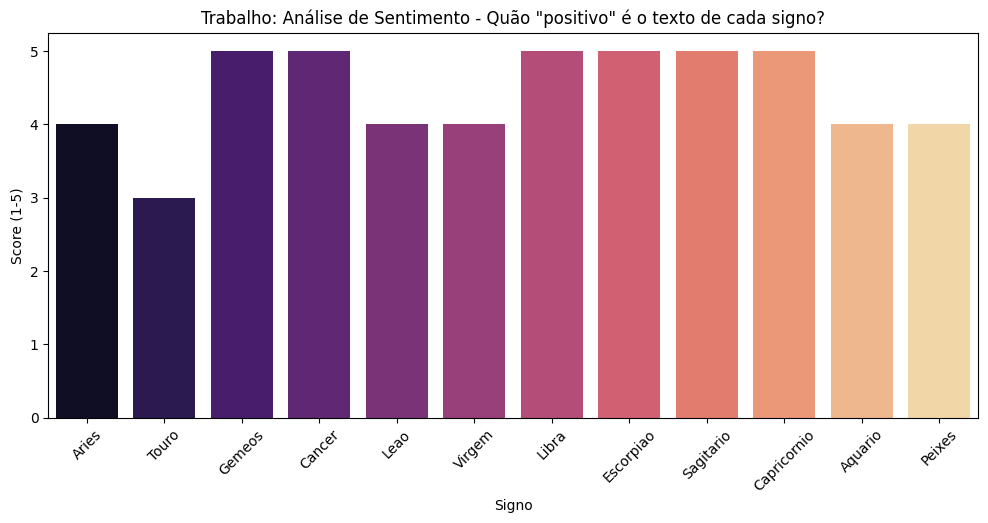

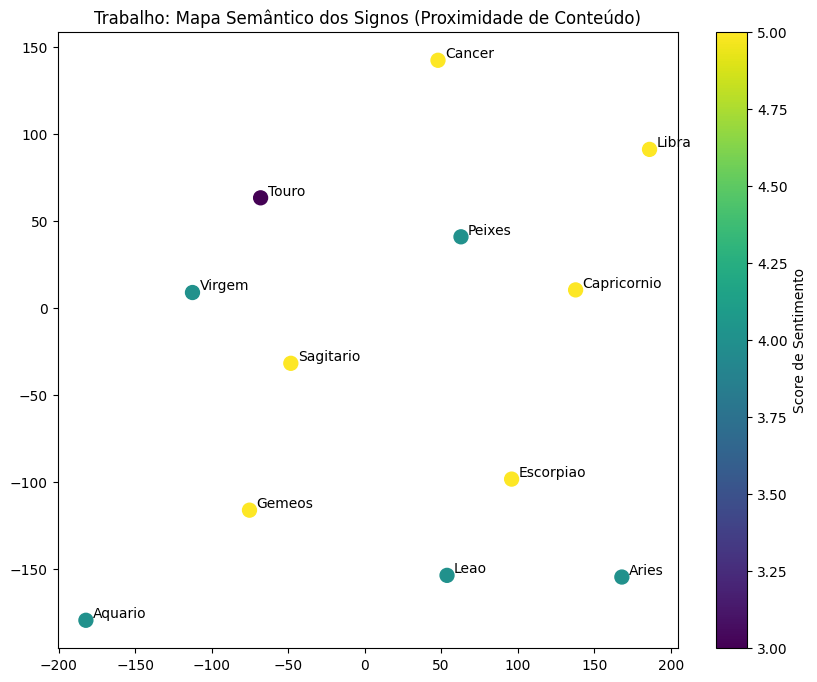


EXEMPLO DE PROCESSAMENTO DE LINGUAGEM NATURAL (Áries)
Signo: Aries

1. Sentenças (primeiras 2): ['Seus principais atributos – a coragem e o dinamismo – são seus diferenciais na vida profissional.', 'Eles que levam você a abraçar posições de comando e a transformar ideias em empreendimentos reais.']

2. Entidades Nomeadas (NER): []

3. Noun Chunks (primeiros 5): ['Seus principais atributos', '– a coragem', 'o dinamismo', 'vida profissional', 'Eles']

4. Lemas (primeiros 10 sem stopwords): ['principal', 'atributo', 'coragem', 'dinamismo', 'diferencial', 'vida', 'profissional', 'levar', 'abraçar', 'posição']


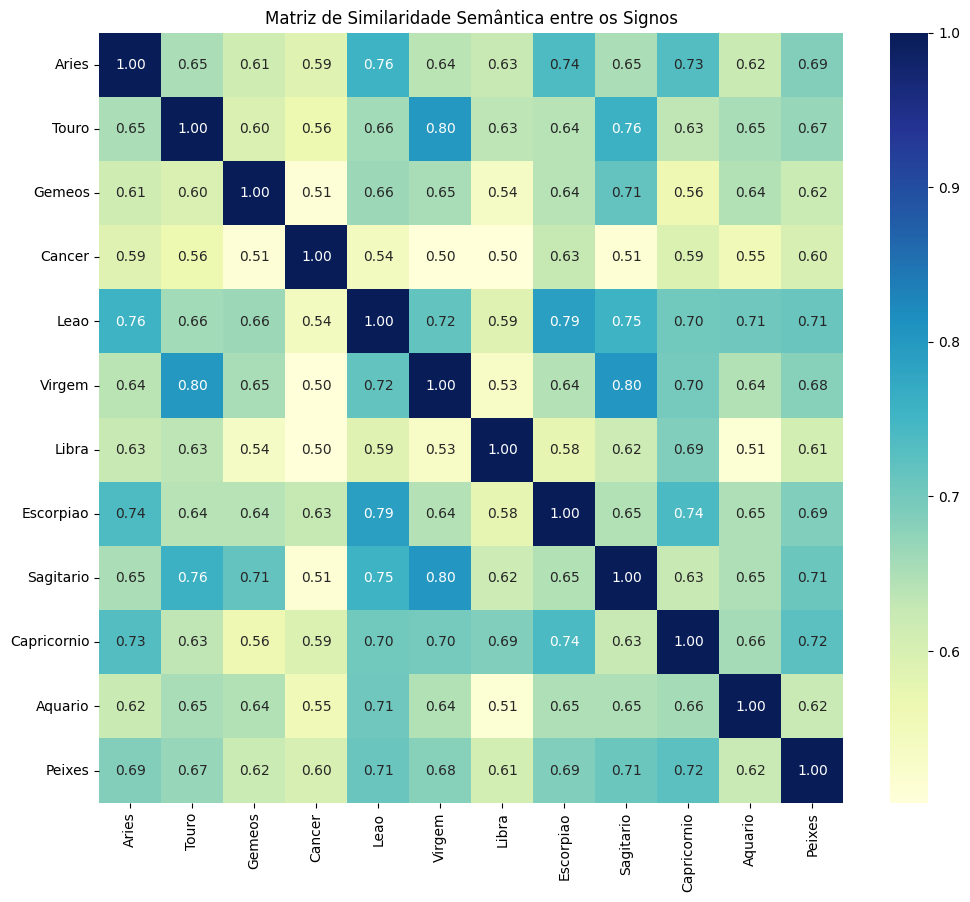

In [55]:
# VISUALIZAÇÃO
# GRÁFICO DE SENTIMENTOS (Trabalho)
plt.figure(figsize=(12, 5))
sns.barplot(x='Signo', y='sentimento_score', data=df, palette='magma')
plt.title('Trabalho: Análise de Sentimento - Quão "positivo" é o texto de cada signo?')
plt.ylabel('Score (1-5)')
plt.xticks(rotation=45)
plt.show()

# MAPA SEMÂNTICO (TSNE)
# Convertendo a lista de embeddings em uma matriz NumPy 2D
matrix_embeddings = np.vstack(df['embeddings'].values)

# Redução de dimensionalidade
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(df)-1), init='pca', learning_rate='auto')
vis_dims = tsne.fit_transform(matrix_embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(vis_dims[:, 0], vis_dims[:, 1], c=df['sentimento_score'], cmap='viridis', s=100)

# Adicionar rótulos aos pontos
for i, signo in enumerate(df['Signo']):
    plt.annotate(signo, (vis_dims[i, 0], vis_dims[i, 1]), xytext=(5, 2), textcoords='offset points')

plt.title('Trabalho: Mapa Semântico dos Signos (Proximidade de Conteúdo)')
plt.colorbar(label='Score de Sentimento')
plt.show()

# DEMONSTRAÇÃO DOS RESULTADOS DE PLN
print("\n" + "="*50)
print("EXEMPLO DE PROCESSAMENTO DE LINGUAGEM NATURAL (Áries)")
print("="*50)
exemplo = df.iloc[0]
print(f"Signo: {exemplo['Signo']}")
print(f"\n1. Sentenças (primeiras 2): {exemplo['sentencas'][:2]}")
print(f"\n2. Entidades Nomeadas (NER): {exemplo['entidades']}")
print(f"\n3. Noun Chunks (primeiros 5): {exemplo['noun_chunks'][:5]}")
print(f"\n4. Lemas (primeiros 10 sem stopwords): {exemplo['lemas'][:10]}")


## Heatmap

# Calcular a matriz de similaridade entre todos os embeddings
# np.stack transforma a coluna de listas em uma matriz 2D
sim_matrix = cosine_similarity(np.stack(df['embeddings'].values))

# Criar o Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(sim_matrix, annot=True, fmt=".2f", cmap='YlGnBu',
            xticklabels=df['Signo'].values,
            yticklabels=df['Signo'].values)

plt.title('Matriz de Similaridade Semântica entre os Signos')
plt.show()

No trabalho, similaridades maiores entre:

* Touro e virgem (terra)
* Leão e áries (fogo)
* Sagitário e leão (fogo)
* Sagitário e virgem (signos mutáveis)
* Leão e escorpião (signos fixo)

### Mapa de palavras (Trabalho)

    Signo                                           Trabalho  \
0   Aries  Seus principais atributos – a coragem e o dina...   
1   Touro  Na vida profissional, você se destaca pela cap...   
2  Gemeos  A criatividade é sua principal arma no mercado...   
3  Cancer  A sua percepção privilegiada é seu diferencial...   
4    Leao  Você encara o trabalho como um campo aberto pa...   

                                       Lemas_Analise  
0  [principal, atributo, coragem, dinamismo, dife...  
1  [vida, profissional, capacidade, trabalho, sen...  
2  [criatividade, principal, arma, mercado, traba...  
3  [percepção, privilegiar, diferencial, competit...  
4  [trabalho, campo, genialidade, ação, pessoa, c...  
Tópicos Dominantes no Horóscopo de Hoje:
Tópico 0: 0.041*"trabalho" + 0.022*"colega" + 0.022*"mercado" + 0.015*"vida" + 0.015*"profissional" + 0.015*"mundo" + 0.015*"cargo" + 0.015*"atividade" + 0.015*"ideal" + 0.015*"emprego"
Tópico 1: 0.028*"trabalho" + 0.016*"ação" + 0.016*"signo" 

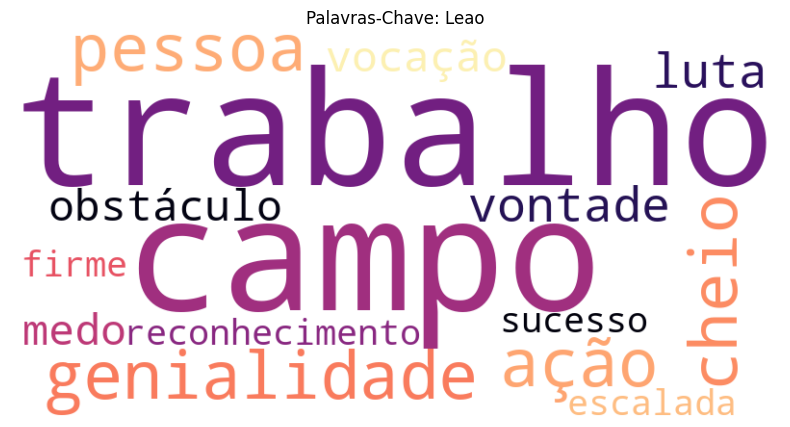

In [56]:
# Selecionar categoria:
categ = 'Trabalho' # < Preencher aqui

# Aplicando a função à coluna da categoria
df_final['Lemas_Analise'] = df_final[categ].apply(processar_para_analise)

# Para verificar o resultado
print(df_final[['Signo', categ, 'Lemas_Analise']].head())

# Análise de Tópicos (LDA)
dicionario = corpora.Dictionary(df_final['Lemas_Analise'])
corpus = [dicionario.doc2bow(text) for text in df_final['Lemas_Analise']]

lda_model = models.LdaModel(corpus, num_topics=3, id2word=dicionario, passes=15)

print("Tópicos Dominantes no Horóscopo de Hoje:")
for idx, topic in lda_model.print_topics(-1):
    print(f"Tópico {idx}: {topic}")

# Exemplo de núvem, selecionando o signo de Leão:
mostrar_nuvem('Leao')